In [1]:
import numpy as np
import matplotlib.pyplot as plt

Parameters

In [2]:
m = 1
V1 = 3
sigma1 = 0.5
V2 = 5
sigma2 = 0.4
b = 1
gamma = 0.3
x0 = -0.5
v0 = 2

## **Part (a): Potential Landscape**

**Part (i)**

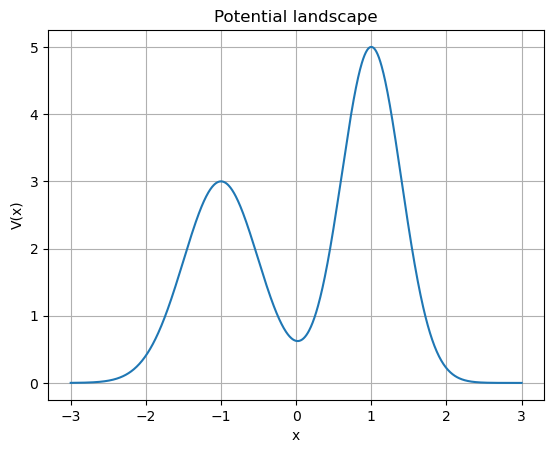

In [ ]:
# Potential function
def V(x):
    return V1*np.exp(-(x+b)**2/(2*sigma1**2)) + V2*np.exp(-(x-b)**2/(2*sigma2**2))

# x-grid
xi, xf = -3, 3
N = 1000
xs = np.linspace(xi, xf, N)
# Potential
Vs = V(xs)

# Plotting
plt.plot(xs, Vs)
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Potential landscape")

plt.grid()
plt.show()

**Left Gaussian hill:**

Height = 3

Position: $x = -1$

**Right Gaussian hill:**

Height = 5

Position: $x = 1$

Location of valley floor: $x = 0$


**Part (ii)**

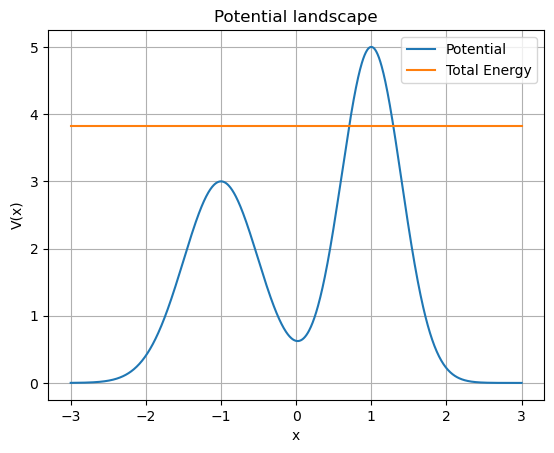

In [4]:
V0 = V(x0)
E0 = 1/2*m*v0**2 + V0

plt.plot(xs, Vs, label = "Potential")
plt.plot([xi, xf], [E0, E0], label = "Total Energy")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Potential landscape")

plt.legend()
plt.grid()
plt.show()

The classically accessible region is below the orange line for total energy. The particle is not able to surmount the right hill if there is no drag.

## **Part (b): Numerical Integration**

**Part (i)**

We consider:

$x = y[0] \\
v = y[1]
$

In [5]:
# RK4
def rk4(f1, x, y, h, gamma):
    k1 = h * f1(x, y, gamma)
    k2 = h * f1(x + h / 2, y + k1 / 2, gamma)
    k3 = h * f1(x + h / 2, y + k2 / 2, gamma)
    k4 = h * f1(x + h, y + k3, gamma)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

# RK4 caller
def caller(fn, y_ini, N, xs, h, gamma):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)

    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = rk4(fn, x, y, h, gamma)
    return ys

# dV/dx
def dV_dx(x):
    return V1*(x+b)/sigma1**2*np.exp(-(x+b)**2/(2*sigma1**2)) + V2*(x-b)/sigma2**2*np.exp(-(x-b)**2/(2*sigma2**2))

# d/dt [x v]
def f1(t, y, gamma):
    return np.asarray([y[1], 1/m*(-dV_dx(y[0]) - gamma*y[1])])


Implementing RK4

In [7]:
ti, tf = 0, 30
dt = 1e-3
Y0 = np.array([x0, v0])     # Initial conditions
N = int((tf - ti)/dt) + 1
ts = np.linspace(ti, tf, N)     # Time grid

Ys = caller(f1, Y0, N, ts, dt, gamma)

**Part (ii)**: Plotting

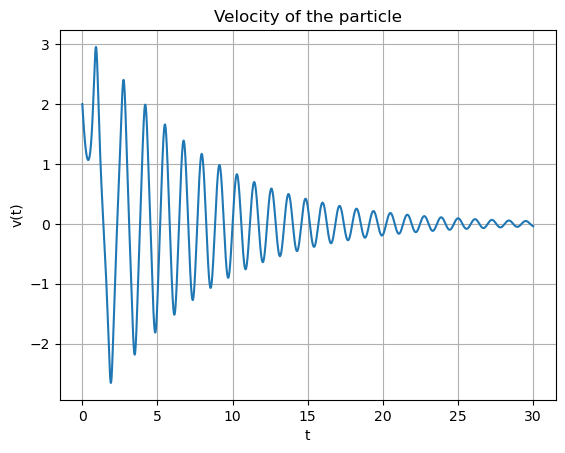

In [8]:
plt.plot(ts, Ys[:, 1])
plt.xlabel("t")
plt.ylabel("v(t)")
plt.title("Velocity of the particle")

plt.grid()
plt.show()
